To recreate the plots, 5 pairs of graphs will be created to compare the performance of each classifier for different feature selection methods.

Finding best k for MI features...
Best k: 1, Max Accuracy: 0.7341666666666666
Finding best k for IG features...
Best k: 35, Max Accuracy: 0.8133333333333334
Finding best k for CHI features...
Best k: 39, Max Accuracy: 0.8041666666666667
Finding best k for DF features...
Best k: 31, Max Accuracy: 0.8141666666666667


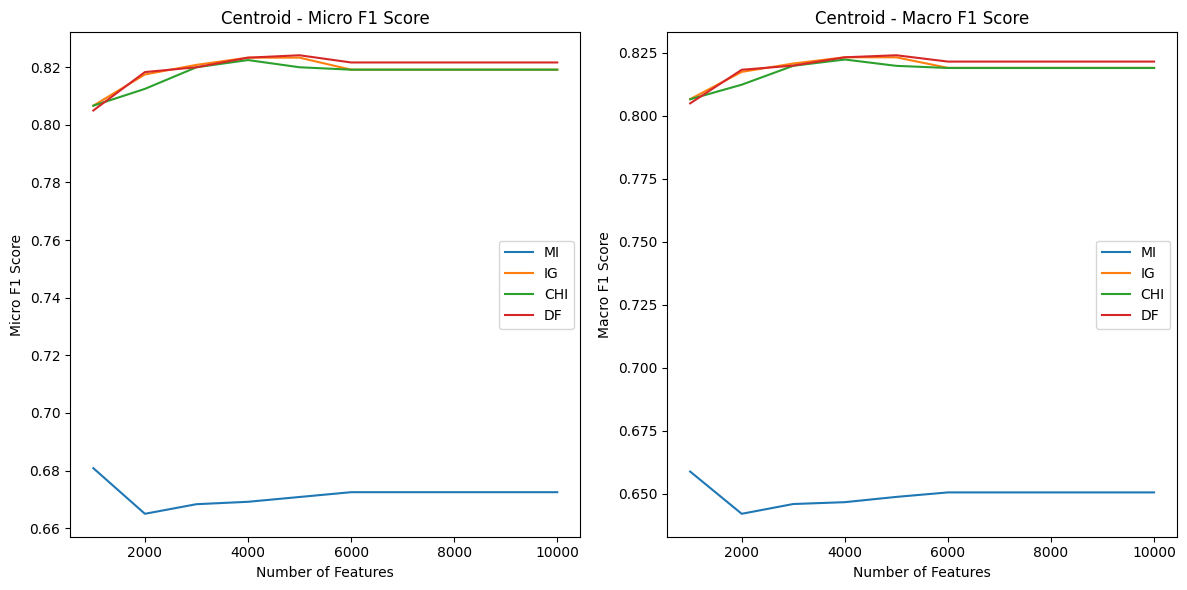

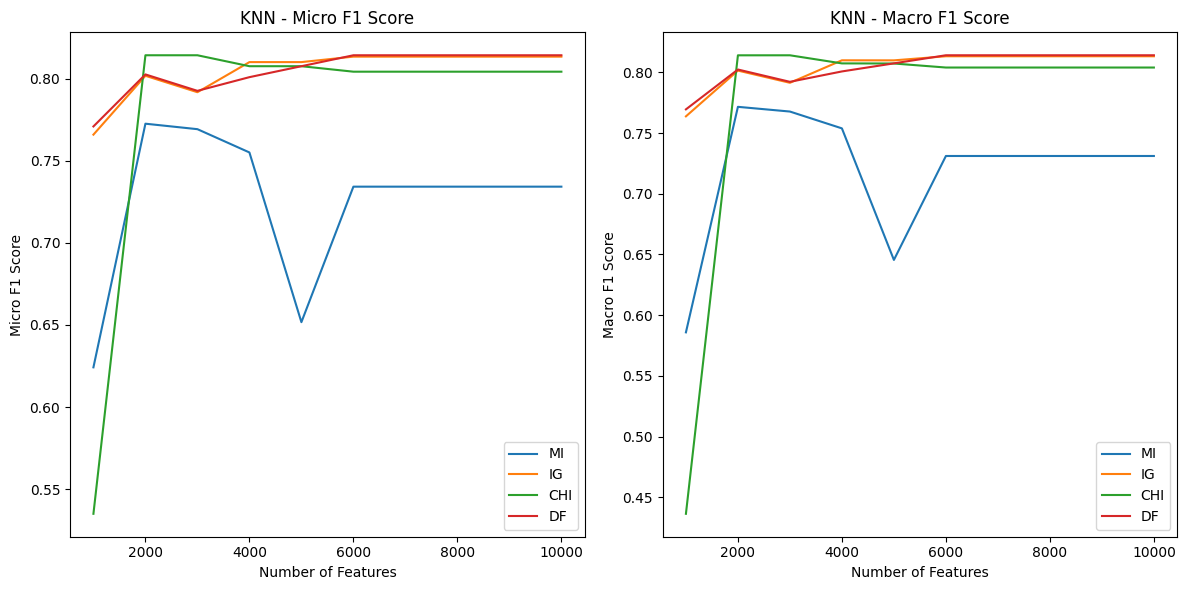

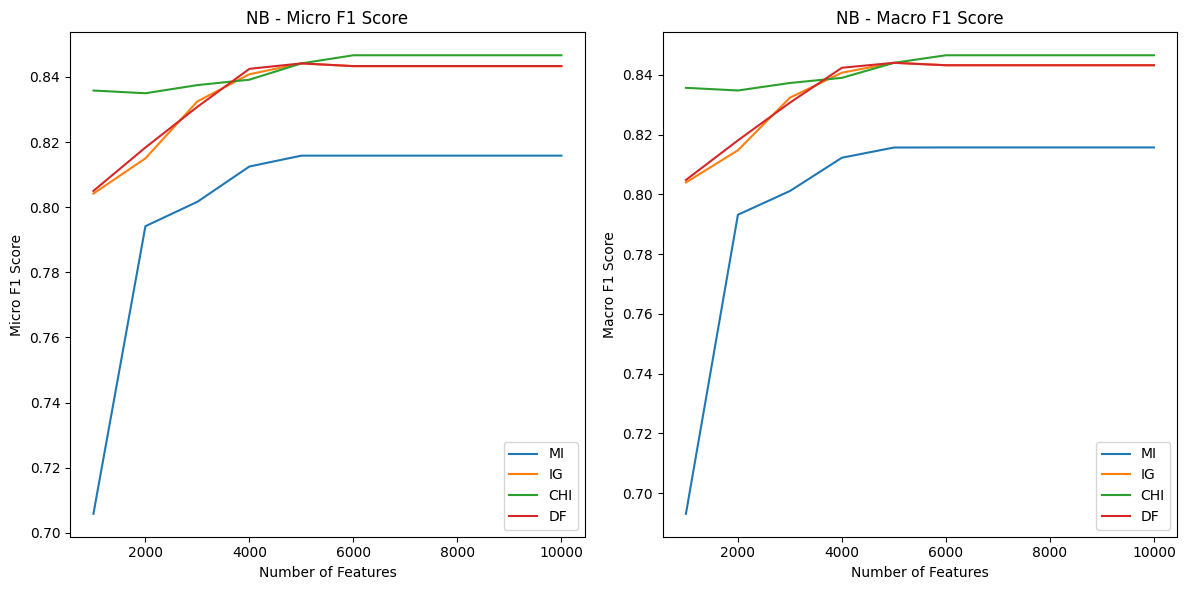

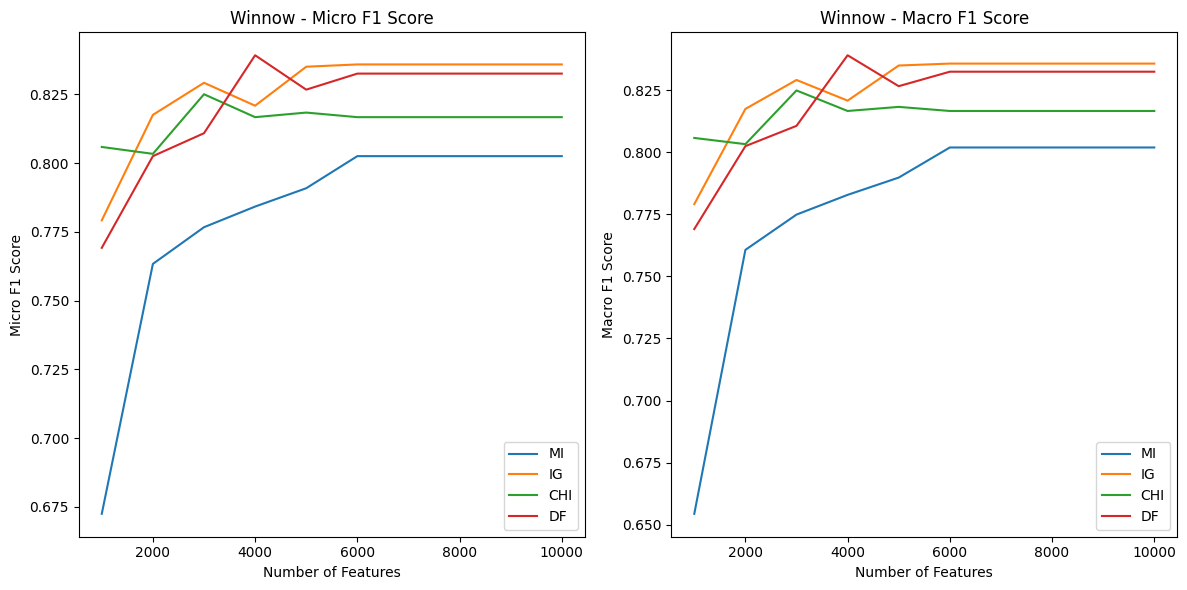

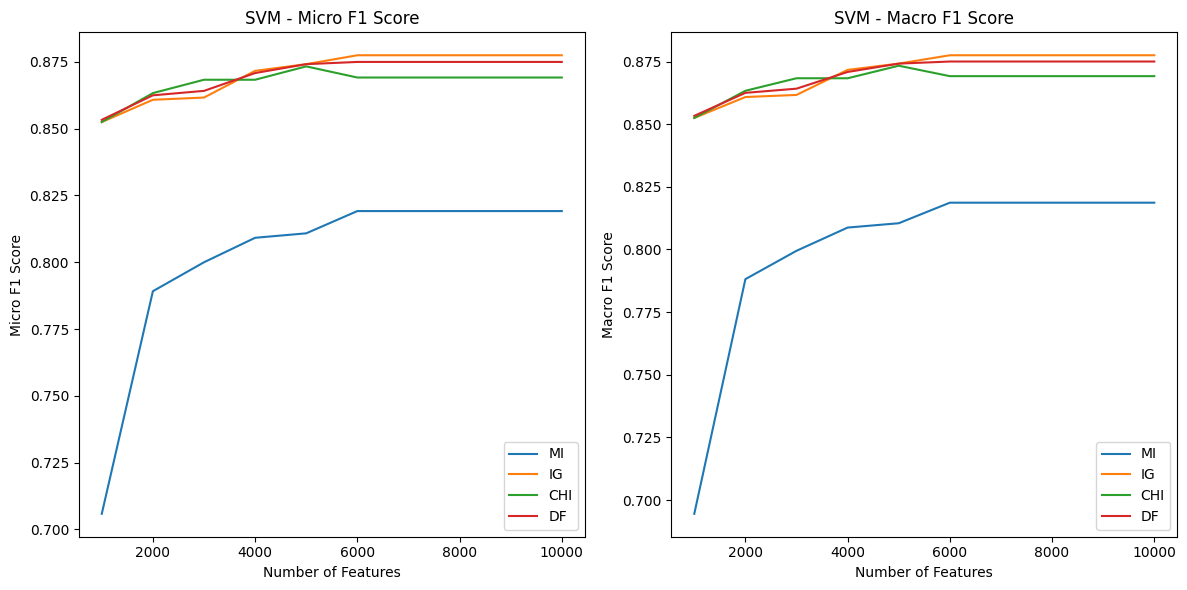

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.feature_selection import chi2
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from scipy.sparse import csr_matrix
from models import CentroidClassifier, KNeighborsClassifier, MultinomialNB, SVC, BalancedWinnow
from pynlpir import nlpir
import pynlpir
import random

random.seed(42)
np.random.seed(42)

pynlpir.open()


# ChnSentiCorp dataset from open source
splits = {
    'train': 'data/train-00000-of-00001-02f200ca5f2a7868.parquet',
    'validation': 'data/validation-00000-of-00001-405befbaa3bcf1a2.parquet',
    'test': 'data/test-00000-of-00001-5372924f059fe767.parquet'
}

df = pd.read_parquet("hf://datasets/lansinuote/ChnSentiCorp/" + splits["train"])
val_df = pd.read_parquet("hf://datasets/lansinuote/ChnSentiCorp/" + splits["validation"])
test_df = pd.read_parquet("hf://datasets/lansinuote/ChnSentiCorp/" + splits["test"])

df['cut_text'] = df['text'].apply(lambda x: ' '.join(pynlpir.segment(x, pos_tagging=False)))
val_df['val_cut_text'] = val_df['text'].apply(lambda x: ' '.join(pynlpir.segment(x, pos_tagging=False)))
test_df['test_cut_text'] = test_df['text'].apply(lambda x: ' '.join(pynlpir.segment(x, pos_tagging=False)))

# Vectorize text
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['cut_text'])
X_val = vectorizer.transform(val_df['val_cut_text'])
X_test = vectorizer.transform(test_df['test_cut_text'])
y = df['label']
y_val = val_df['label']
y_test = test_df['label']

# Calculate MI using the definition in the paper
def calculate_mi_vectorized(X, y, class_labels):
    y_binary = np.array([y == c for c in class_labels]).T

    # count co-occurrence
    A = X.T.dot(y_binary)  # t&c_i
    B = X.sum(axis=0).reshape(-1, 1)- A  # t
    E = y_binary.sum(axis=0)- A  # c_i
    D = X.shape[0]- (A + B + E)  # none
    A = np.where(A == 0, 1, A)
    B = np.where(B == 0, 1, B)
    E = np.where(E == 0, 1, E)
    D = np.where(D == 0, 1, D)

    #features*classes
    N = X.shape[0]
    mi_scores = np.log((A*N)/ ((A+E)* (A+B)))
    return np.max(mi_scores, axis=1)

def select_features_mi(X, y, feature_names, k=10000):
    class_labels = np.unique(y)
    mi_scores = calculate_mi_vectorized(X, y, class_labels)
    mi_scores_dict = {word: score for word, score in zip(feature_names, mi_scores)}
    sorted_mi_scores = sorted(mi_scores_dict.items(), key=lambda x: x[1], reverse=True)
    top_k_features = [word for word, score in sorted_mi_scores[:k]]
    return top_k_features

# IG based on paper definition
def information_gain(X, y, feature_index):
    #calculate entropy
    def entropy(y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return -np.sum(probabilities * np.log2(probabilities + 1e-10))

    def conditional_entropy(X_feature, y):
        unique_values = np.unique(X_feature)
        conditional_entropy = 0
        for value in unique_values:
            subset_indices = X_feature == value
            subset_y = y[subset_indices]
            if len(subset_y) > 0:
                conditional_entropy += (len(subset_y) / len(y)) * entropy(subset_y)
        return conditional_entropy

    #calculate IG
    total_entropy = entropy(y)
    conditional_entropy_value = conditional_entropy(X[:, feature_index], y)
    information_gain = total_entropy - conditional_entropy_value
    return information_gain

def select_features_ig(X, y, feature_names, k=10000):
    feature_indices = {feature: index for index, feature in enumerate(feature_names)}
    X = X.toarray()
    ig_scores = []
    for feature in feature_names:
        feature_index = feature_indices[feature]
        ig_score = information_gain(X, y, feature_index)
        ig_scores.append(ig_score)
    ig_scores_dict = {word: score for word, score in zip(feature_names, ig_scores)}
    sorted_ig_scores = sorted(ig_scores_dict.items(), key=lambda x: x[1], reverse=True)
    top_k_features = [word for word, score in sorted_ig_scores[:k]]
    return top_k_features

#chi according to the definition of the paper
def calculate_chi_vectorized(X, y, class_labels):
    y_binary = np.array([y == c for c in class_labels]).T

    A = X.T.dot(y_binary)
    B = X.sum(axis=0).reshape(-1, 1) - A
    E = y_binary.sum(axis=0) - A
    D = X.shape[0] - (A + B + E)
    A = np.where(A == 0, 1, A)
    B = np.where(B == 0, 1, B)
    E = np.where(E == 0, 1, E)
    D = np.where(D == 0, 1, D)
    N = X.shape[0]
    chi_scores = N*np.square(A*D-B*E)/((A+E)*(B+D)*(A+B)*(E+D))
    return np.max(chi_scores, axis=1)

def select_features_chi(X, y, feature_names, k=10000):
    class_labels = np.unique(y)
    chi_scores = calculate_chi_vectorized(X, y, class_labels)

    chi_scores_dict = {word: score for word, score in zip(feature_names, chi_scores)}
    sorted_chi_scores = sorted(chi_scores_dict.items(), key=lambda x: x[1], reverse=True)
    top_k_features = [word for word, score in sorted_chi_scores[:k]]
    return top_k_features

#df
def select_features_df(X, feature_names, k=10000):
    df_scores = np.sum(X.toarray() > 0, axis=0)
    df_dict = dict(zip(feature_names, df_scores))
    counter = Counter(df_dict)
    top_k_features = [word for word, freq in counter.most_common(k)]
    return top_k_features

feature_names = vectorizer.get_feature_names_out()
# Select features
top_k_mi = select_features_mi(X, y, feature_names, k=6000)  # Use optimized MI calculation
top_k_ig = select_features_ig(X, y, feature_names, k=6000)
top_k_chi = select_features_chi(X, y, feature_names, k=6000)
top_k_df = select_features_df(X, feature_names, k=6000)

# Create feature sets
feature_sets = {
    'MI': (TfidfVectorizer(vocabulary=top_k_mi), top_k_mi),
    'IG': (TfidfVectorizer(vocabulary=top_k_ig), top_k_ig),
    'CHI': (TfidfVectorizer(vocabulary=top_k_chi), top_k_chi),
    'DF': (TfidfVectorizer(vocabulary=top_k_df), top_k_df)
}

# Transform data
X_train_mi = feature_sets['MI'][0].fit_transform(df['cut_text'])
X_test_mi = feature_sets['MI'][0].transform(test_df['test_cut_text'])

X_train_ig = feature_sets['IG'][0].fit_transform(df['cut_text'])
X_test_ig = feature_sets['IG'][0].transform(test_df['test_cut_text'])

X_train_chi = feature_sets['CHI'][0].fit_transform(df['cut_text'])
X_test_chi = feature_sets['CHI'][0].transform(test_df['test_cut_text'])

X_train_df = feature_sets['DF'][0].fit_transform(df['cut_text'])
X_test_df = feature_sets['DF'][0].transform(test_df['test_cut_text'])

classifiers = {
    'Centroid': CentroidClassifier(),
    'KNN': KNeighborsClassifier(),
    'NB': MultinomialNB(),
    'Winnow': BalancedWinnow(),
    'SVM': SVC(kernel='linear')
}

#store F1 scores, range up till 10000
micro_f1_scores = {clf: {fs: [] for fs in feature_sets} for clf in classifiers}
macro_f1_scores = {clf: {fs: [] for fs in feature_sets} for clf in classifiers}
num_features_range = range(1000, 10001, 1000)

#Find best k for knn
def find_best_k(X_train, y_train, X_val, y_val, k_range=range(1, 40)):
    accuracy = []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_val)
        accuracy.append(accuracy_score(y_val, y_pred))
    best_k = k_range[np.argmax(accuracy)]
    print(f"Best k: {best_k}, Max Accuracy: {max(accuracy)}")
    return best_k

best_k_values = {}
for fs_name, (vectorizer, features) in feature_sets.items():
    X_train_fs = vectorizer.fit_transform(df['cut_text'])
    X_test_fs = vectorizer.transform(test_df['test_cut_text'])
    best_k = find_best_k(X_train_fs, y, X_test_fs, y_test)
    best_k_values[fs_name] = best_k

# Iterate over the number of features
for num_features in num_features_range:
    for clf_name, clf in classifiers.items():
        for fs_name, (vectorizer, features) in feature_sets.items():
            selected_features = features[:num_features]
            filtered_vectorizer = TfidfVectorizer(vocabulary=selected_features)
            X_train_fs = filtered_vectorizer.fit_transform(df['cut_text'])
            X_test_fs = filtered_vectorizer.transform(test_df['test_cut_text'])
            # Convert to more dense matrices
            if clf_name in ['Centroid', 'Winnow']:
                X_train_fs_dense = X_train_fs.toarray()
                X_test_fs_dense = X_test_fs.toarray()
            else:
                X_train_fs_dense = X_train_fs
                X_test_fs_dense = X_test_fs

            if clf_name == 'KNN':
                clf = KNeighborsClassifier(n_neighbors=best_k_values[fs_name])
            clf.fit(X_train_fs_dense, y)
            y_pred = clf.predict(X_test_fs_dense)
            # micro and macro F1 score
            micro_f1 = f1_score(y_test, y_pred, average='micro')
            macro_f1 = f1_score(y_test, y_pred, average='macro')
            micro_f1_scores[clf_name][fs_name].append(micro_f1)
            macro_f1_scores[clf_name][fs_name].append(macro_f1)

# Plots
for clf_name in classifiers:
    plt.figure(figsize=(12, 6))

    # Micro
    plt.subplot(1, 2, 1)
    for fs_name in feature_sets:
        plt.plot(num_features_range, micro_f1_scores[clf_name][fs_name], label=fs_name)
    plt.title(f'{clf_name} - Micro F1 Score')
    plt.xlabel('Number of Features')
    plt.ylabel('Micro F1 Score')
    plt.legend()

    # Macro
    plt.subplot(1, 2, 2)
    for fs_name in feature_sets:
        plt.plot(num_features_range, macro_f1_scores[clf_name][fs_name], label=fs_name)
    plt.title(f'{clf_name} - Macro F1 Score')
    plt.xlabel('Number of Features')
    plt.ylabel('Macro F1 Score')
    plt.legend()

    plt.tight_layout()
    plt.show()